<a href="https://colab.research.google.com/github/bobo33772-blip/AI_study/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import keras
# keras.datasets.imdb.load_data()

from keras.datasets import imdb
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=100)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(25000,)
(25000,)
(25000,)
(25000,)


In [3]:
print(x_train[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 2, 36, 2, 5, 25, 2, 43, 2, 2, 50, 2, 2, 9, 35, 2, 2, 5, 2, 4, 2, 2, 2, 2, 2, 2, 39, 4, 2, 2, 2, 17, 2, 38, 13, 2, 4, 2, 50, 16, 6, 2, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 2, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 2, 12, 16, 38, 2, 5, 25, 2, 51, 36, 2, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 2, 2, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 2, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 2, 6, 2, 2, 18, 4, 2, 22, 21, 2, 2, 26, 2, 5, 2, 30, 2, 18, 51, 36, 28, 2, 92, 25, 2, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 2, 2, 32, 15, 16, 2, 19, 2, 32]


In [4]:
print(y_train[0:10])

[1 0 0 1 0 0 1 0 1 0]


In [5]:
# 단어별 숫자
word_index = imdb.get_word_index()

In [6]:
# 단어별 번호
# 단어 : 번호
type(word_index)

dict

In [7]:
# 내용 확인
word_index.keys() # 리뷰에 사용된 단어들
word_index.values() # 단어들에게 매겨진 번호
len(word_index.items()) # (단어:숫자).....

88584

In [8]:
word_index['hello']
# 숫자: 단어 형태의 사전생성
index_word = {v:k for k,v in word_index.items()}

In [9]:
def decode_review(text, index_word_map):
  word_map = {
      1: "<START>",
      2: "<UNK>",
      3: "<PAD>",
      # 4 and above map to actual words, shifted by 3
  }
  decoded_words = [word_map.get(i, index_word_map.get(i - 3, '?')) for i in text]
  return " ".join(decoded_words)

`decode_review` 함수는 숫자로 된 영화 리뷰를 다시 단어 문자열로 변환하는 데 도움이 됩니다. IMDB 데이터셋은 '시작', '알 수 없는 단어', '패딩'에 대한 특별한 인덱스를 사용하므로, 이를 올바르게 매핑하고 다른 단어 인덱스를 3만큼 조정해야 합니다.

In [10]:
# 첫 번째 훈련 리뷰 (x_train[0]) 디코딩
decoded_first_review = decode_review(x_train[0], index_word)
print(decoded_first_review)

<START> this film was just <UNK> <UNK> <UNK> <UNK> story <UNK> <UNK> really <UNK> the <UNK> they <UNK> and you <UNK> just <UNK> <UNK> there <UNK> <UNK> is an <UNK> <UNK> and <UNK> the <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> from the <UNK> <UNK> <UNK> as <UNK> so i <UNK> the <UNK> there was a <UNK> <UNK> with this film the <UNK> <UNK> <UNK> the film were great it was just <UNK> so much that i <UNK> the film as <UNK> as it was <UNK> for <UNK> and would <UNK> it to <UNK> to <UNK> and the <UNK> <UNK> was <UNK> really <UNK> at the <UNK> it was so <UNK> and you <UNK> what they <UNK> if you <UNK> at a film it <UNK> have been good and this <UNK> was also <UNK> to the <UNK> <UNK> <UNK> that <UNK> the <UNK> of <UNK> and <UNK> they were just <UNK> <UNK> are <UNK> <UNK> out of the <UNK> <UNK> i <UNK> because the <UNK> that <UNK> them all <UNK> up are <UNK> a <UNK> <UNK> for the <UNK> film but <UNK> <UNK> are <UNK> and <UNK> be <UNK> for what they have <UNK> don't you <UNK> the <UNK> story was so <UNK>

In [11]:
def decode_review(text, index_word_map):
  word_map = {
      1: "<START>",
      2: "<UNK>",
      3: "<PAD>",
      # 4 and above map to actual words, shifted by 3
  }
  decoded_words = [word_map.get(i, index_word_map.get(i - 3, '?')) for i in text]
  return " ".join(decoded_words)

The `decode_review` function helps convert the numerical movie review back into a string of words. The IMDB dataset uses special indices for 'start of sequence', 'unknown word', and 'padding', so we need to map those correctly and adjust the other word indices by 3.

In [12]:
# Decode the first training review (x_train[0])
decoded_first_review = decode_review(x_train[0], index_word)
print(decoded_first_review)

<START> this film was just <UNK> <UNK> <UNK> <UNK> story <UNK> <UNK> really <UNK> the <UNK> they <UNK> and you <UNK> just <UNK> <UNK> there <UNK> <UNK> is an <UNK> <UNK> and <UNK> the <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> from the <UNK> <UNK> <UNK> as <UNK> so i <UNK> the <UNK> there was a <UNK> <UNK> with this film the <UNK> <UNK> <UNK> the film were great it was just <UNK> so much that i <UNK> the film as <UNK> as it was <UNK> for <UNK> and would <UNK> it to <UNK> to <UNK> and the <UNK> <UNK> was <UNK> really <UNK> at the <UNK> it was so <UNK> and you <UNK> what they <UNK> if you <UNK> at a film it <UNK> have been good and this <UNK> was also <UNK> to the <UNK> <UNK> <UNK> that <UNK> the <UNK> of <UNK> and <UNK> they were just <UNK> <UNK> are <UNK> <UNK> out of the <UNK> <UNK> i <UNK> because the <UNK> that <UNK> them all <UNK> up are <UNK> a <UNK> <UNK> for the <UNK> film but <UNK> <UNK> are <UNK> and <UNK> be <UNK> for what they have <UNK> don't you <UNK> the <UNK> story was so <UNK>

In [13]:
# print(x_train[0])
# # print( index_word[2] )
# for n in x_train[0]:
#   print( index_word[ n-3 ] if n-3>=0 else '?')

In [14]:
# train, test로 나누기
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42)

In [15]:
# 문장길이 체크
import numpy as np
# 각 문장의 길이 저장
lengths=[len(x) for x in X_train]
print('min length',min(lengths))
print('max length',max(lengths))
print('avg length',sum(lengths)/len(lengths))

min length 11
max length 1854
avg length 239.00925


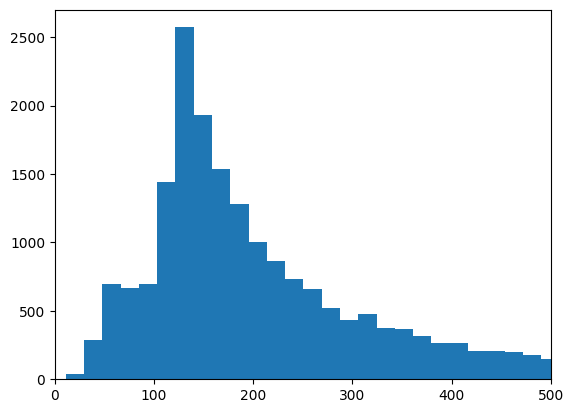

In [16]:
# 문장길이의 히스토그램
import matplotlib.pyplot as plt
plt.hist(lengths, bins=100)
plt.xlim(0,500)
plt.show()

In [17]:
# 리뷰문장 길이는 최대 100단어로 조정
train_seq = keras.preprocessing.sequence.pad_sequences(
    X_train,
    maxlen=100,
    # padding='pre'
    )
test_seq = keras.preprocessing.sequence.pad_sequences(
    x_test,
    maxlen=100,
    # padding='pre'
    )

In [18]:
train_seq.shape

(20000, 100)

In [19]:
train_seq[-10]

array([ 2, 31,  2,  7,  4,  2,  4, 64, 84, 37, 71,  2, 17,  4,  2,  2, 29,
        2,  2,  2,  6,  2,  7, 84,  2, 39,  6,  2,  2,  2,  2, 12,  2,  2,
       39, 94,  2,  2,  2,  2,  2,  2,  8,  2, 44, 89,  2,  2,  9,  5,  2,
        2, 39,  2,  2,  4,  2, 11,  4,  2, 12, 47,  4,  2,  2, 27,  2,  2,
        7,  6,  2,  2,  2, 83,  2,  2,  5,  2,  8,  2, 90, 44,  2,  4,  2,
       50,  2,  2,  5, 82,  4,  2,  2, 43, 93,  4, 22,  2,  8,  2],
      dtype=int32)

In [20]:
model=keras.Sequential()
model.add(keras.layers.Input(shape=(100,100)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [21]:
train_oh = keras.utils.to_categorical(train_seq)
test_oh = keras.utils.to_categorical(test_seq)

In [22]:
train_oh.shape

(20000, 100, 100)

In [23]:
train_oh[0][0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [24]:
# whos

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model.fit(
    train_oh,
    y_train,
    epochs=100,
    batch_size=64,
    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5020 - loss: 0.6975
Epoch 2/100
  4/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4880 - loss: 0.6949 

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5332 - loss: 0.6891
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.5684 - loss: 0.6766
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6069 - loss: 0.6595
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6139 - loss: 0.6528
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6036 - loss: 0.6752
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5884 - loss: 0.6679
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6274 - loss: 0.6523
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5515 - loss: 0.6822
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5563 - loss: 0.6796
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5666 - loss: 0.6745
Epoch 12/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5844 - loss: 0.6662
Epoch 13/100
313/313 ━━━━━━━━━━━━━━━━━